<div class="alert alert-danger" role="alert">
<h1 align="center"><font size = 14>Deep-Learning (Part3)</font></h1>
<h4 align="center">Aug, 10_2026<h4>
<h3 align="center">Armin Amani</h3>

<div class="alert alert-danger" role="alert">
📤 Import Libraries

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

import tensorflow as tf
from sklearn.metrics import classification_report

<div class="alert alert-danger" role="alert"> 
💾 Read Data

In [2]:
(train_images, train_labels), (test_images, test_labels) = tf.keras.datasets.cifar10.load_data()

In [3]:
print(f"shape of the training features is : {train_images.shape}")
print(f"shape of the training labels is : {train_labels.shape}")
print(f"shape of the testing features is : {test_images.shape}")
print(f"shape of the testing labels is : {test_labels.shape}")

shape of the training features is : (50000, 32, 32, 3)
shape of the training labels is : (50000, 1)
shape of the testing features is : (10000, 32, 32, 3)
shape of the testing labels is : (10000, 1)


<div class="alert alert-danger" role="alert"> 
🔎 normalize train_images and test_images

In [4]:
train_images = train_images.astype('float32') / 255.0
test_images = test_images.astype('float32') / 255.0

<div class="alert alert-danger" role="alert"> 
🔎 one-hot on labels

In [5]:
train_labels = tf.keras.utils.to_categorical(train_labels, 10)
test_labels = tf.keras.utils.to_categorical(test_labels, 10)

In [6]:
train_labels

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 1.],
       [0., 0., 0., ..., 0., 0., 1.],
       ...,
       [0., 0., 0., ..., 0., 0., 1.],
       [0., 1., 0., ..., 0., 0., 0.],
       [0., 1., 0., ..., 0., 0., 0.]], dtype=float32)

In [7]:
test_labels

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 1., 0.],
       [0., 0., 0., ..., 0., 1., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 1., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 1., 0., 0.]], dtype=float32)

<div class="alert alert-danger" role="alert"> 
🔎 Define model architecture parameters

In [8]:
input_num_units = 32 * 32 * 3
hidden1_num_units = 256
hidden2_num_units = 128
hidden3_num_units = 64
hidden4_num_units = 32
hidden5_num_units = 16
output_num_units = 10
epochs = 30
batch_size = 64

<div class="alert alert-danger" role="alert"> 
🔎 a) simple_model (with no Data augmentation)

In [9]:
simple_model = tf.keras.Sequential([
    tf.keras.layers.Flatten(input_shape=(32, 32, 3)),
    tf.keras.layers.Dense(hidden1_num_units, activation='relu'),
    tf.keras.layers.Dense(hidden2_num_units, activation='relu'),
    tf.keras.layers.Dense(hidden3_num_units, activation='relu'),
    tf.keras.layers.Dense(hidden4_num_units, activation='relu'),
    tf.keras.layers.Dense(hidden5_num_units, activation='relu'),
    tf.keras.layers.Dense(output_num_units, activation='softmax'),
])


In [10]:
simple_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

In [11]:
history_simple = simple_model.fit(train_images, train_labels, epochs=epochs, batch_size=batch_size, validation_split=0.2)


Epoch 1/30
625/625 [==============================] - 4s 5ms/step - loss: 2.0604 - accuracy: 0.2291 - val_loss: 1.8845 - val_accuracy: 0.3131
Epoch 2/30
625/625 [==============================] - 2s 4ms/step - loss: 1.8117 - accuracy: 0.3458 - val_loss: 1.7935 - val_accuracy: 0.3531
Epoch 3/30
625/625 [==============================] - 2s 4ms/step - loss: 1.7204 - accuracy: 0.3755 - val_loss: 1.7333 - val_accuracy: 0.3801
Epoch 4/30
625/625 [==============================] - 2s 4ms/step - loss: 1.6654 - accuracy: 0.3970 - val_loss: 1.7020 - val_accuracy: 0.3913
Epoch 5/30
625/625 [==============================] - 3s 4ms/step - loss: 1.6130 - accuracy: 0.4218 - val_loss: 1.6666 - val_accuracy: 0.4023
Epoch 6/30
625/625 [==============================] - 3s 4ms/step - loss: 1.5703 - accuracy: 0.4367 - val_loss: 1.6387 - val_accuracy: 0.4183
Epoch 7/30
625/625 [==============================] - 2s 4ms/step - loss: 1.5414 - accuracy: 0.4484 - val_loss: 1.6045 - val_accuracy: 0.4251
Epoch 

<div class="alert alert-danger" role="alert"> 
🔎 Data augmentation

In [12]:
datagen = tf.keras.preprocessing.image.ImageDataGenerator(
    rotation_range=10,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    horizontal_flip=False
)

In [13]:
augment_data = datagen.flow(train_images, train_labels, batch_size=train_images.shape[0], shuffle=False)

In [14]:
train_feature_aug, train_label_aug = next(augment_data)

In [15]:
train_feature_aug.shape

(50000, 32, 32, 3)

In [16]:
train_label_aug.shape

(50000, 10)

<div class="alert alert-danger" role="alert"> 
🔎 concate artificial data with real data

In [17]:
train_images_augment = np.concatenate((train_images, train_feature_aug))
train_labels_augment = np.concatenate((train_labels, train_label_aug))

In [18]:
train_images_augment = train_images_augment.reshape((train_images_augment.shape[0], -1))
test_images = test_images.reshape((test_images.shape[0], -1))

In [19]:
print(f"shape of train_images_augment is : {train_images_augment.shape}")
print(f"shape of test_images is : {test_images.shape}")

shape of train_images_augment is : (100000, 3072)
shape of test_images is : (10000, 3072)


<div class="alert alert-danger" role="alert"> 
🔎 b) l1_model

In [20]:
model_l1 = tf.keras.models.Sequential([
    tf.keras.layers.Dense(hidden1_num_units, input_dim=input_num_units, activation='relu', kernel_regularizer=tf.keras.regularizers.l1(0.0001)),
    tf.keras.layers.Dense(hidden2_num_units, activation='relu', kernel_regularizer=tf.keras.regularizers.l1(0.0001)),
    tf.keras.layers.Dense(hidden3_num_units, activation='relu', kernel_regularizer=tf.keras.regularizers.l1(0.0001)),
    tf.keras.layers.Dense(hidden4_num_units, activation='relu', kernel_regularizer=tf.keras.regularizers.l1(0.0001)),
    tf.keras.layers.Dense(hidden5_num_units, activation='relu', kernel_regularizer=tf.keras.regularizers.l1(0.0001)),
    tf.keras.layers.Dense(output_num_units, activation='softmax')
])

In [21]:
model_l1.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

In [22]:
history_l1 = model_l1.fit(train_images_augment, train_labels_augment, epochs=epochs, validation_data=(test_images, test_labels), batch_size=batch_size)

Epoch 1/30
1563/1563 [==============================] - 14s 6ms/step - loss: 2.2157 - accuracy: 0.2708 - val_loss: 1.9362 - val_accuracy: 0.3366
Epoch 2/30
1563/1563 [==============================] - 8s 5ms/step - loss: 1.9330 - accuracy: 0.3403 - val_loss: 1.8646 - val_accuracy: 0.3678
Epoch 3/30
1563/1563 [==============================] - 7s 5ms/step - loss: 1.8787 - accuracy: 0.3586 - val_loss: 1.7928 - val_accuracy: 0.3892
Epoch 4/30
1563/1563 [==============================] - 7s 5ms/step - loss: 1.8329 - accuracy: 0.3790 - val_loss: 1.7579 - val_accuracy: 0.4063
Epoch 5/30
1563/1563 [==============================] - 7s 5ms/step - loss: 1.7979 - accuracy: 0.3935 - val_loss: 1.7720 - val_accuracy: 0.4087
Epoch 6/30
1563/1563 [==============================] - 7s 5ms/step - loss: 1.7689 - accuracy: 0.4067 - val_loss: 1.6983 - val_accuracy: 0.4362
Epoch 7/30
1563/1563 [==============================] - 7s 5ms/step - loss: 1.7421 - accuracy: 0.4180 - val_loss: 1.6935 - val_accuracy

<div class="alert alert-danger" role="alert"> 
🔎 C) l2_model

In [23]:
model_l2 = tf.keras.models.Sequential([
    tf.keras.layers.Dense(hidden1_num_units, input_dim=input_num_units, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(0.0001)),
    tf.keras.layers.Dense(hidden2_num_units, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(0.0001)),
    tf.keras.layers.Dense(hidden3_num_units, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(0.0001)),
    tf.keras.layers.Dense(hidden4_num_units, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(0.0001)),
    tf.keras.layers.Dense(hidden5_num_units, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(0.0001)),
    tf.keras.layers.Dense(output_num_units, activation='softmax')
])

In [24]:
model_l2.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

In [25]:
history_l2 = model_l2.fit(train_images_augment, train_labels_augment, epochs=epochs, validation_data=(test_images, test_labels), batch_size=batch_size)

Epoch 1/30
1563/1563 [==============================] - 7s 4ms/step - loss: 1.9552 - accuracy: 0.2956 - val_loss: 1.7052 - val_accuracy: 0.3988
Epoch 2/30
1563/1563 [==============================] - 6s 4ms/step - loss: 1.7313 - accuracy: 0.3873 - val_loss: 1.7025 - val_accuracy: 0.4048
Epoch 3/30
1563/1563 [==============================] - 6s 4ms/step - loss: 1.6450 - accuracy: 0.4207 - val_loss: 1.6033 - val_accuracy: 0.4391
Epoch 4/30
1563/1563 [==============================] - 7s 4ms/step - loss: 1.6027 - accuracy: 0.4394 - val_loss: 1.5531 - val_accuracy: 0.4559
Epoch 5/30
1563/1563 [==============================] - 7s 4ms/step - loss: 1.5744 - accuracy: 0.4525 - val_loss: 1.5162 - val_accuracy: 0.4758
Epoch 6/30
1563/1563 [==============================] - 6s 4ms/step - loss: 1.5555 - accuracy: 0.4612 - val_loss: 1.5067 - val_accuracy: 0.4787
Epoch 7/30
1563/1563 [==============================] - 7s 4ms/step - loss: 1.5411 - accuracy: 0.4653 - val_loss: 1.5305 - val_accuracy:

<div class="alert alert-danger" role="alert"> 
🔎 D) model_elastic

In [26]:
model_elastic = tf.keras.models.Sequential([
    tf.keras.layers.Dense(hidden1_num_units, input_dim=input_num_units, activation='relu', kernel_regularizer=tf.keras.regularizers.l1_l2(l1=0.0001, l2=0.0001)),
    tf.keras.layers.Dense(hidden2_num_units, activation='relu', kernel_regularizer=tf.keras.regularizers.l1_l2(l1=0.0001, l2=0.0001)),
    tf.keras.layers.Dense(hidden3_num_units, activation='relu', kernel_regularizer=tf.keras.regularizers.l1_l2(l1=0.0001, l2=0.0001)),
    tf.keras.layers.Dense(hidden4_num_units, activation='relu', kernel_regularizer=tf.keras.regularizers.l1_l2(l1=0.0001, l2=0.0001)),
    tf.keras.layers.Dense(hidden5_num_units, activation='relu', kernel_regularizer=tf.keras.regularizers.l1_l2(l1=0.0001, l2=0.0001)),
    tf.keras.layers.Dense(output_num_units, activation='softmax')
])

In [27]:
model_elastic.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

In [28]:
history_elastic = model_elastic.fit(train_images_augment, train_labels_augment, epochs=epochs, validation_data=(test_images, test_labels), batch_size=batch_size)

Epoch 1/30
1563/1563 [==============================] - 9s 5ms/step - loss: 2.2636 - accuracy: 0.2858 - val_loss: 1.9068 - val_accuracy: 0.3736
Epoch 2/30
1563/1563 [==============================] - 8s 5ms/step - loss: 1.9126 - accuracy: 0.3613 - val_loss: 1.8411 - val_accuracy: 0.3792
Epoch 3/30
1563/1563 [==============================] - 8s 5ms/step - loss: 1.8324 - accuracy: 0.3854 - val_loss: 1.7285 - val_accuracy: 0.4229
Epoch 4/30
1563/1563 [==============================] - 10s 6ms/step - loss: 1.7913 - accuracy: 0.3997 - val_loss: 1.7417 - val_accuracy: 0.4213
Epoch 5/30
1563/1563 [==============================] - 9s 5ms/step - loss: 1.7686 - accuracy: 0.4104 - val_loss: 1.7505 - val_accuracy: 0.4187
Epoch 6/30
1563/1563 [==============================] - 8s 5ms/step - loss: 1.7499 - accuracy: 0.4185 - val_loss: 1.7585 - val_accuracy: 0.4073
Epoch 7/30
1563/1563 [==============================] - 8s 5ms/step - loss: 1.7390 - accuracy: 0.4219 - val_loss: 1.6753 - val_accuracy

<div class="alert alert-danger" role="alert"> 
🔎 E) model_early_stopping

In [29]:
early_stopping_model = tf.keras.models.Sequential([
    tf.keras.layers.Dense(hidden1_num_units, input_dim=input_num_units, activation='relu'),
    tf.keras.layers.Dense(hidden2_num_units, activation='relu'),
    tf.keras.layers.Dense(hidden3_num_units, activation='relu'),
    tf.keras.layers.Dense(hidden4_num_units, activation='relu'),
    tf.keras.layers.Dense(hidden5_num_units, activation='relu'),
    tf.keras.layers.Dense(output_num_units, activation='softmax')
])

In [30]:
early_stopping_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

In [31]:
early_stopping = tf.keras.callbacks.EarlyStopping(monitor='val_accuracy', patience=2)
history_early_stopping = early_stopping_model.fit(train_images_augment, train_labels_augment, epochs=epochs, validation_data=(test_images, test_labels), batch_size=batch_size, callbacks=[early_stopping])

Epoch 1/30
1563/1563 [==============================] - 6s 4ms/step - loss: 1.9356 - accuracy: 0.2834 - val_loss: 1.7898 - val_accuracy: 0.3441
Epoch 2/30
1563/1563 [==============================] - 6s 4ms/step - loss: 1.7160 - accuracy: 0.3819 - val_loss: 1.6188 - val_accuracy: 0.4124
Epoch 3/30
1563/1563 [==============================] - 6s 4ms/step - loss: 1.6169 - accuracy: 0.4195 - val_loss: 1.5321 - val_accuracy: 0.4502
Epoch 4/30
1563/1563 [==============================] - 6s 4ms/step - loss: 1.5548 - accuracy: 0.4422 - val_loss: 1.4877 - val_accuracy: 0.4721
Epoch 5/30
1563/1563 [==============================] - 6s 4ms/step - loss: 1.5153 - accuracy: 0.4564 - val_loss: 1.4904 - val_accuracy: 0.4775
Epoch 6/30
1563/1563 [==============================] - 6s 4ms/step - loss: 1.4816 - accuracy: 0.4701 - val_loss: 1.4527 - val_accuracy: 0.4815
Epoch 7/30
1563/1563 [==============================] - 6s 4ms/step - loss: 1.4542 - accuracy: 0.4811 - val_loss: 1.4252 - val_accuracy:

<div class="alert alert-danger" role="alert"> 
🔎 F) combined models

In [32]:
combined_model = tf.keras.models.Sequential([
    tf.keras.layers.Dense(hidden1_num_units, input_dim=input_num_units, activation='relu', kernel_regularizer=tf.keras.regularizers.l1(0.0001)),
    tf.keras.layers.Dense(hidden2_num_units, activation='relu', kernel_regularizer=tf.keras.regularizers.l1(0.0001)),
    tf.keras.layers.Dense(hidden3_num_units, activation='relu', kernel_regularizer=tf.keras.regularizers.l1(0.0001)),
    tf.keras.layers.Dense(hidden4_num_units, activation='relu', kernel_regularizer=tf.keras.regularizers.l1(0.0001)),
    tf.keras.layers.Dense(hidden5_num_units, activation='relu', kernel_regularizer=tf.keras.regularizers.l1(0.0001)),
    tf.keras.layers.Dense(output_num_units, activation='softmax')
])

In [33]:
combined_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

In [34]:
early_stopping = tf.keras.callbacks.EarlyStopping(monitor='val_accuracy', patience=8)
history_combined = combined_model.fit(train_images_augment, train_labels_augment, epochs=epochs, validation_data=(test_images, test_labels), batch_size=batch_size, callbacks=[early_stopping])

Epoch 1/30
1563/1563 [==============================] - 8s 5ms/step - loss: 2.2491 - accuracy: 0.2610 - val_loss: 2.0088 - val_accuracy: 0.3286
Epoch 2/30
1563/1563 [==============================] - 7s 4ms/step - loss: 1.9165 - accuracy: 0.3514 - val_loss: 1.8054 - val_accuracy: 0.3877
Epoch 3/30
1563/1563 [==============================] - 7s 4ms/step - loss: 1.8373 - accuracy: 0.3734 - val_loss: 1.7734 - val_accuracy: 0.4024
Epoch 4/30
1563/1563 [==============================] - 7s 5ms/step - loss: 1.7957 - accuracy: 0.3911 - val_loss: 1.7340 - val_accuracy: 0.4166
Epoch 5/30
1563/1563 [==============================] - 7s 4ms/step - loss: 1.7626 - accuracy: 0.4057 - val_loss: 1.6923 - val_accuracy: 0.4406
Epoch 6/30
1563/1563 [==============================] - 7s 4ms/step - loss: 1.7441 - accuracy: 0.4128 - val_loss: 1.7067 - val_accuracy: 0.4206
Epoch 7/30
1563/1563 [==============================] - 7s 5ms/step - loss: 1.7259 - accuracy: 0.4208 - val_loss: 1.6639 - val_accuracy:

<div class="alert alert-danger" role="alert"> 
⬛⬜⬛⬜⬛⬜ Plot

In [35]:
results = {
    'simple_model':history_simple.history,
    'l1_regularization':history_l1.history,
    'l2_regularixation':history_l2.history,
    'elastic':history_elastic.history,
    'early_stopping':history_early_stopping.history,
    'combined model':history_combined.history
}

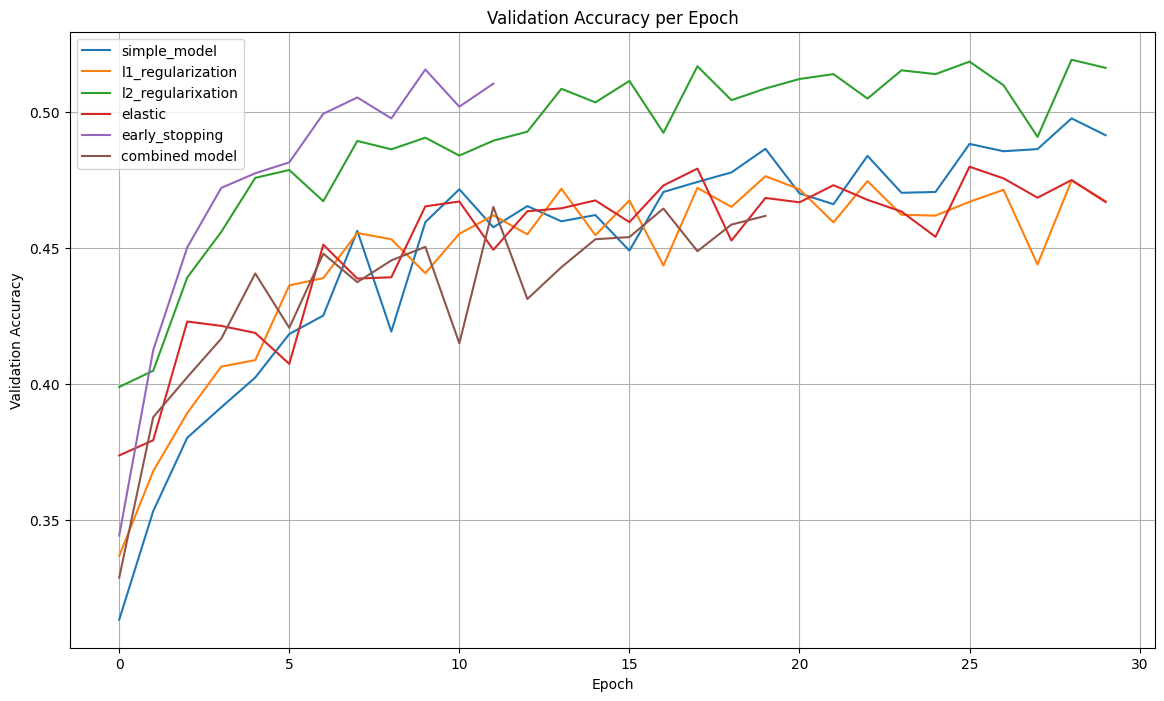

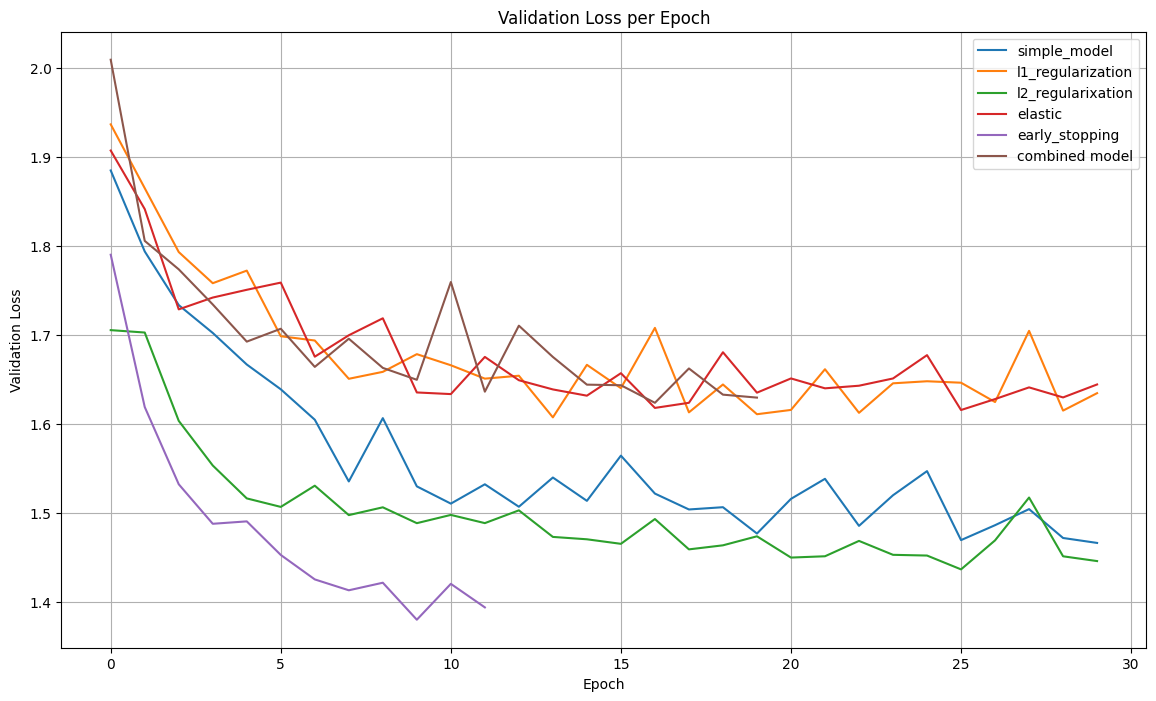

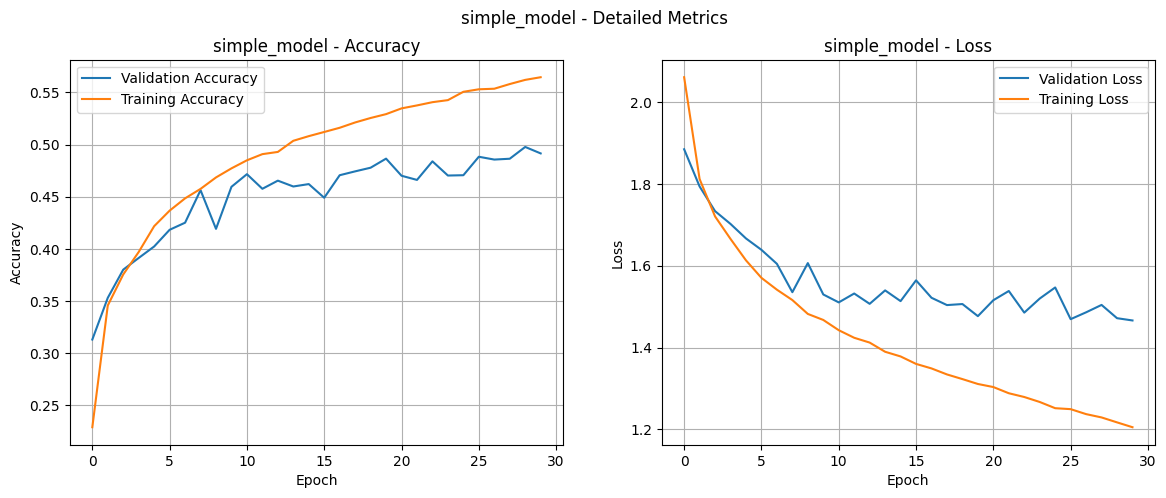

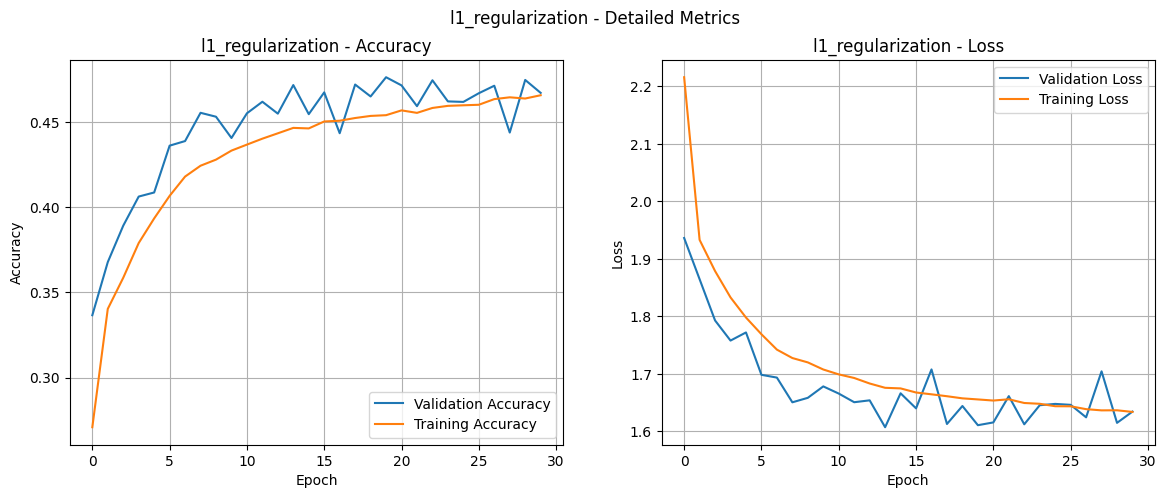

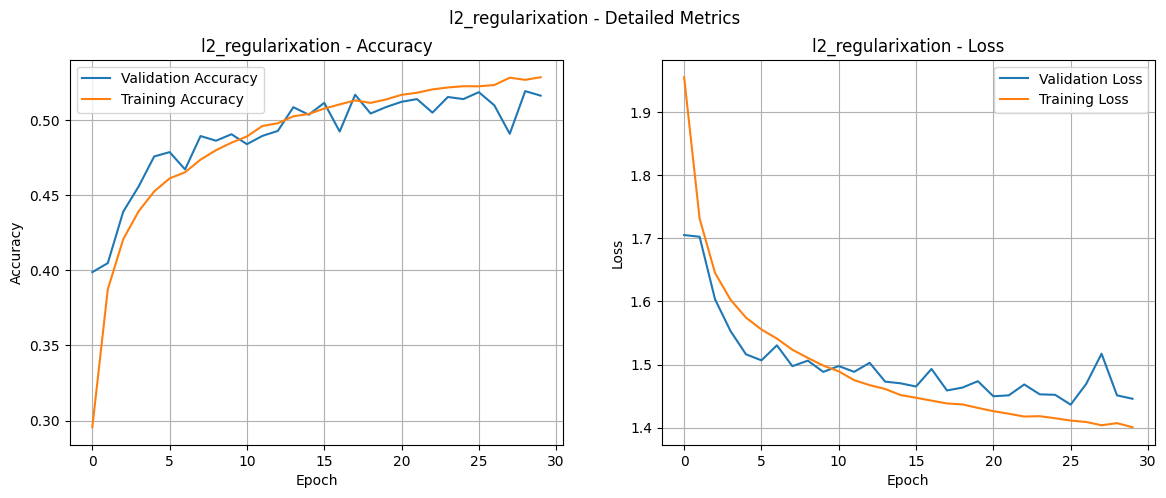

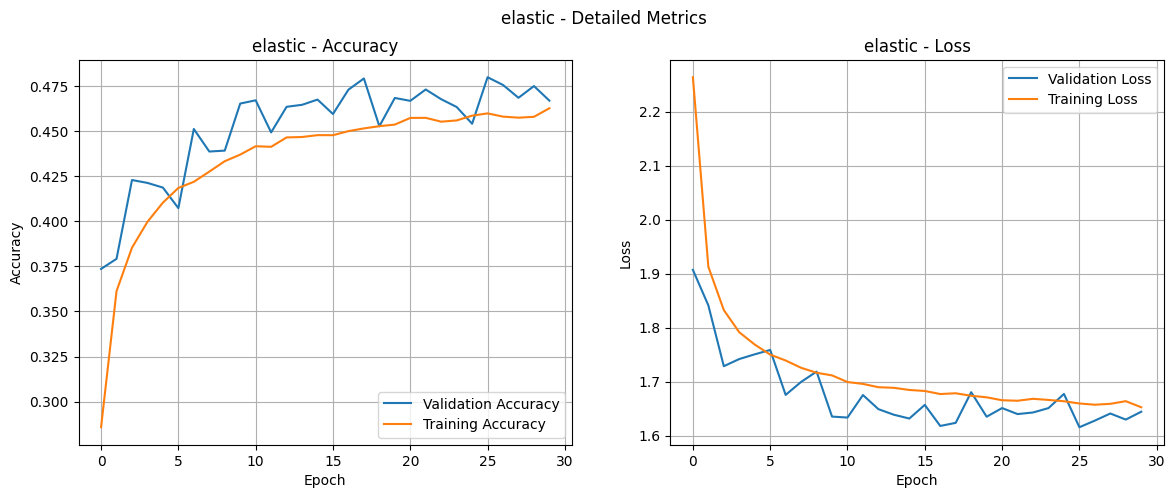

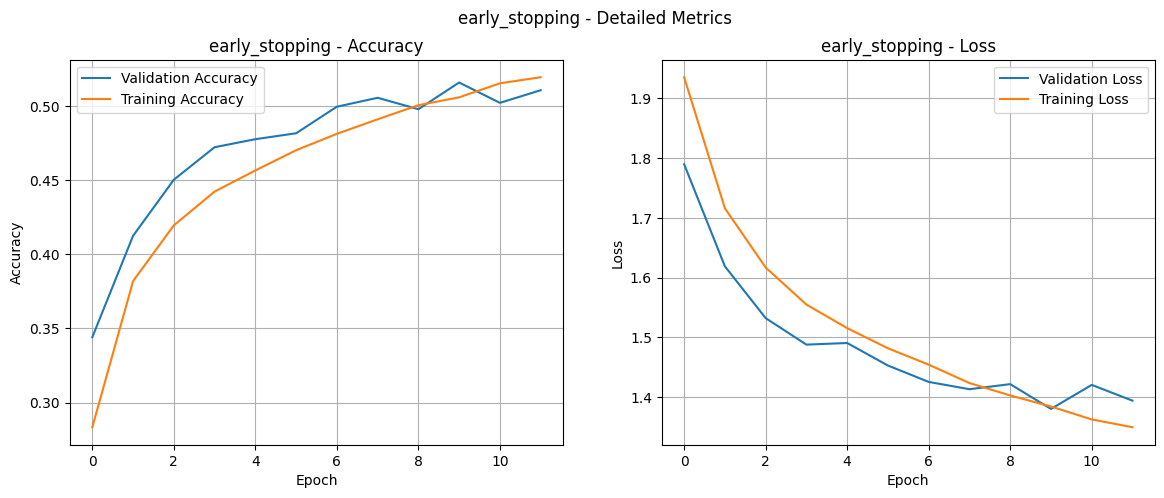

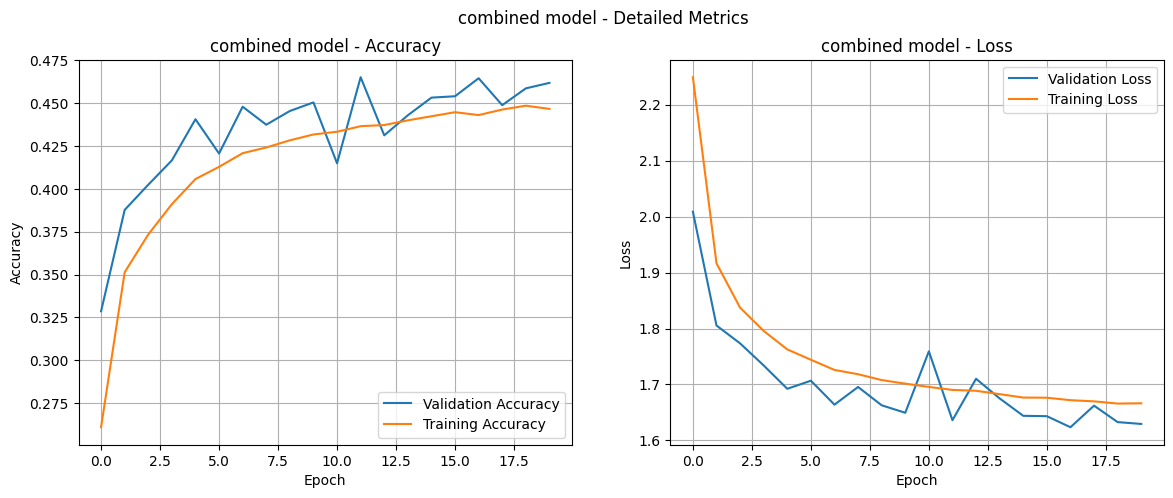

In [36]:
# Plot accuracy for each model
plt.figure(figsize=(14, 8))
for key in results.keys():
    plt.plot(results[key]['val_accuracy'], label=key)
plt.title('Validation Accuracy per Epoch')
plt.xlabel('Epoch')
plt.ylabel('Validation Accuracy')
plt.legend()
plt.grid(True)
plt.show()

# Plot loss for each model
plt.figure(figsize=(14, 8))
for key in results.keys():
    plt.plot(results[key]['val_loss'], label=key)
plt.title('Validation Loss per Epoch')
plt.xlabel('Epoch')
plt.ylabel('Validation Loss')
plt.legend()
plt.grid(True)
plt.show()

# Plot detailed accuracy and loss for each model
for key in results.keys():
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    ax1.plot(results[key]['val_accuracy'], label='Validation Accuracy')
    ax1.plot(results[key]['accuracy'], label='Training Accuracy')
    ax1.set_title(f'{key} - Accuracy')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Accuracy')
    ax1.legend()
    ax1.grid(True)

    ax2.plot(results[key]['val_loss'], label='Validation Loss')
    ax2.plot(results[key]['loss'], label='Training Loss')
    ax2.set_title(f'{key} - Loss')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Loss')
    ax2.legend()
    ax2.grid(True)

    plt.suptitle(f'{key} - Detailed Metrics')
    plt.show()

In [ ]:
# Armin Amani